In [1]:
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import joblib

## Import Required Libraries

The necessary Python libraries are imported for data processing, machine learning, model evaluation, model saving, and API development.

In [2]:
df = pd.read_csv("customer_churn_ltv_final.csv")

## Load the Dataset

The cleaned customer churn dataset is loaded into a pandas DataFrame. This dataset will be used for both churn prediction and Customer Lifetime Value (LTV) prediction.

In [3]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 7043
Columns : 26


In [4]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn',
 'Avg_Revenue_Per_Month',
 'Customer_Age_Group',
 'Customer_Segment',
 'LTV',
 'LTV_Segment']

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customerID             7043 non-null   int64  
 1   gender                 7043 non-null   int64  
 2   SeniorCitizen          7043 non-null   int64  
 3   Partner                7043 non-null   int64  
 4   Dependents             7043 non-null   int64  
 5   tenure                 7043 non-null   int64  
 6   PhoneService           7043 non-null   int64  
 7   MultipleLines          7043 non-null   int64  
 8   InternetService        7043 non-null   int64  
 9   OnlineSecurity         7043 non-null   int64  
 10  OnlineBackup           7043 non-null   int64  
 11  DeviceProtection       7043 non-null   int64  
 12  TechSupport            7043 non-null   int64  
 13  StreamingTV            7043 non-null   int64  
 14  StreamingMovies        7043 non-null   int64  
 15  Cont

In [6]:
df.isnull().sum()

customerID               0
gender                   0
SeniorCitizen            0
Partner                  0
Dependents               0
tenure                   0
PhoneService             0
MultipleLines            0
InternetService          0
OnlineSecurity           0
OnlineBackup             0
DeviceProtection         0
TechSupport              0
StreamingTV              0
StreamingMovies          0
Contract                 0
PaperlessBilling         0
PaymentMethod            0
MonthlyCharges           0
TotalCharges             0
Churn                    0
Avg_Revenue_Per_Month    0
Customer_Age_Group       0
Customer_Segment         0
LTV                      0
LTV_Segment              0
dtype: int64

In [7]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [8]:
if "customerID" in df.columns:
    df.drop("customerID", axis=1, inplace=True)

print(df.columns.tolist())

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'Avg_Revenue_Per_Month', 'Customer_Age_Group', 'Customer_Segment', 'LTV', 'LTV_Segment']


In [9]:
df.dtypes

gender                     int64
SeniorCitizen              int64
Partner                    int64
Dependents                 int64
tenure                     int64
PhoneService               int64
MultipleLines              int64
InternetService            int64
OnlineSecurity             int64
OnlineBackup               int64
DeviceProtection           int64
TechSupport                int64
StreamingTV                int64
StreamingMovies            int64
Contract                   int64
PaperlessBilling           int64
PaymentMethod              int64
MonthlyCharges           float64
TotalCharges             float64
Churn                      int64
Avg_Revenue_Per_Month    float64
Customer_Age_Group         int64
Customer_Segment          object
LTV                      float64
LTV_Segment               object
dtype: object

## Load the Dataset

The cleaned customer churn dataset is loaded into a pandas DataFrame. This dataset will be used for both churn prediction and Customer Lifetime Value (LTV) prediction.

In [10]:
categorical_columns = df.select_dtypes(include="object").columns.tolist()

categorical_columns

['Customer_Segment', 'LTV_Segment']

In [11]:
label_encoders = {}

for column in categorical_columns:
    encoder = LabelEncoder()

    df[column] = encoder.fit_transform(df[column])

    label_encoders[column] = encoder

print("Encoding completed successfully!")

Encoding completed successfully!


In [12]:
df.dtypes

gender                     int64
SeniorCitizen              int64
Partner                    int64
Dependents                 int64
tenure                     int64
PhoneService               int64
MultipleLines              int64
InternetService            int64
OnlineSecurity             int64
OnlineBackup               int64
DeviceProtection           int64
TechSupport                int64
StreamingTV                int64
StreamingMovies            int64
Contract                   int64
PaperlessBilling           int64
PaymentMethod              int64
MonthlyCharges           float64
TotalCharges             float64
Churn                      int64
Avg_Revenue_Per_Month    float64
Customer_Age_Group         int64
Customer_Segment           int64
LTV                      float64
LTV_Segment                int64
dtype: object

## Encode Categorical Variables

Categorical columns are converted into numerical values using Label Encoding so that machine learning models can process the data.

In [13]:
joblib.dump(label_encoders, "label_encoders.pkl")

print("Label Encoders Saved Successfully!")

Label Encoders Saved Successfully!


In [14]:
for column, encoder in label_encoders.items():
    print(f"\n{column}")
    print(dict(zip(encoder.classes_, encoder.transform(encoder.classes_))))


Customer_Segment
{'High Value': np.int64(0), 'Low Value': np.int64(1), 'Medium Value': np.int64(2)}

LTV_Segment
{'Bronze': np.int64(0), 'Gold': np.int64(1), 'Platinum': np.int64(2), 'Silver': np.int64(3)}


In [15]:
X_churn = df.drop(columns=["Churn"])

y_churn = df["Churn"]

## Prepare Data for Churn Prediction

The dataset is divided into input features and the target variable (Churn). It is then split into training and testing datasets.

In [16]:
X_train_churn, X_test_churn, y_train_churn, y_test_churn = train_test_split(
    X_churn,
    y_churn,
    test_size=0.2,
    random_state=42,
    stratify=y_churn
)

In [17]:
X_ltv = df.drop(columns=["LTV", "Churn"])

y_ltv = df["LTV"]

In [18]:
X_train_ltv, X_test_ltv, y_train_ltv, y_test_ltv = train_test_split(
    X_ltv,
    y_ltv,
    test_size=0.2,
    random_state=42
)

## Prepare Data for LTV Prediction

For Customer Lifetime Value prediction, the LTV column is selected as the target variable, while the remaining customer attributes are used as input features.

In [19]:
print("Churn Training Shape :", X_train_churn.shape)
print("Churn Testing Shape  :", X_test_churn.shape)

print()

print("LTV Training Shape :", X_train_ltv.shape)
print("LTV Testing Shape  :", X_test_ltv.shape)

Churn Training Shape : (5634, 24)
Churn Testing Shape  : (1409, 24)

LTV Training Shape : (5634, 23)
LTV Testing Shape  : (1409, 23)


In [20]:
churn_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

churn_model.fit(X_train_churn, y_train_churn)

print("Churn Model Trained Successfully!")

Churn Model Trained Successfully!


## Train the Churn Prediction Model

A Random Forest Classifier is trained using the prepared training dataset to predict whether a customer is likely to churn.

In [21]:
y_pred_churn = churn_model.predict(X_test_churn)

In [22]:
accuracy = accuracy_score(y_test_churn, y_pred_churn)

print(f"Accuracy : {accuracy:.4f}")

Accuracy : 0.7878


In [23]:
print(classification_report(y_test_churn, y_pred_churn))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.63      0.50      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



## Evaluate the Churn Model

The trained model is evaluated using metrics such as Accuracy, Precision, Recall, F1-Score, Classification Report, and Confusion Matrix.

In [24]:
cm = confusion_matrix(y_test_churn, y_pred_churn)

print(cm)

[[924 111]
 [188 186]]


In [25]:
feature_importance = pd.DataFrame({
    "Feature": X_train_churn.columns,
    "Importance": churn_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
18,TotalCharges,0.125830
22,LTV,0.115983
19,Avg_Revenue_Per_Month,0.113424
17,MonthlyCharges,0.113108
4,tenure,0.102304
14,Contract,0.057762
8,OnlineSecurity,0.044126
16,PaymentMethod,0.040316
11,TechSupport,0.036795
9,OnlineBackup,0.025548


## Feature Importance

The feature importance scores are calculated to identify which customer attributes have the greatest impact on churn prediction.

In [26]:
joblib.dump(churn_model, "churn_model.pkl")

print("Churn Model Saved Successfully!")

Churn Model Saved Successfully!


In [27]:
churn_columns = X_train_churn.columns.tolist()

joblib.dump(churn_columns, "churn_columns.pkl")

print("Churn Columns Saved Successfully!")

Churn Columns Saved Successfully!


## Save the Churn Model

The trained churn prediction model and the list of feature columns are saved using Joblib so they can be reused during API deployment.

In [28]:
import os

files = [
    "churn_model.pkl",
    "churn_columns.pkl",
    "label_encoders.pkl"
]

for file in files:
    print(f"{file} :", os.path.exists(file))

churn_model.pkl : True
churn_columns.pkl : True
label_encoders.pkl : True


In [30]:
print(churn_columns)

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Avg_Revenue_Per_Month', 'Customer_Age_Group', 'Customer_Segment', 'LTV', 'LTV_Segment']


In [31]:
X = df[churn_columns]
y = df["Churn"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (7043, 24)
Target Shape: (7043,)


In [32]:
categorical_columns = X.select_dtypes(include="object").columns.tolist()

print(categorical_columns)

[]


In [34]:
from sklearn.model_selection import train_test_split

X = df[churn_columns]
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (5634, 24)
Testing Data: (1409, 24)


In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling Completed")

Scaling Completed


In [36]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

print("Logistic Regression Training Completed")

Logistic Regression Training Completed


In [38]:
from sklearn.model_selection import train_test_split

# Features and target
X = df[churn_columns]
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (5634, 24)
Testing Data: (1409, 24)


In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling Completed")

Scaling Completed


In [40]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

print("Logistic Regression Training Completed")

Logistic Regression Training Completed


In [41]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

print("Decision Tree Training Completed")

Decision Tree Training Completed


In [42]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest Training Completed")

Random Forest Training Completed


## Train the LTV Prediction Model

A Random Forest Regressor is trained to estimate the expected Customer Lifetime Value based on customer characteristics.

In [43]:
# Predictions

log_pred = log_model.predict(X_test_scaled)

dt_pred = dt_model.predict(X_test)

rf_pred = rf_model.predict(X_test)

print("Predictions Completed")

Predictions Completed


In [44]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Store model results

results = []

models = [
    ("Logistic Regression", log_pred),
    ("Decision Tree", dt_pred),
    ("Random Forest", rf_pred)
]


for name, prediction in models:
    results.append([
        name,
        accuracy_score(y_test, prediction),
        precision_score(y_test, prediction),
        recall_score(y_test, prediction),
        f1_score(y_test, prediction)
    ])


results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)


results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.796309,0.635514,0.545455,0.587050
1,Decision Tree,0.721789,0.477273,0.505348,0.490909
2,Random Forest,0.787793,0.626263,0.497326,0.554396


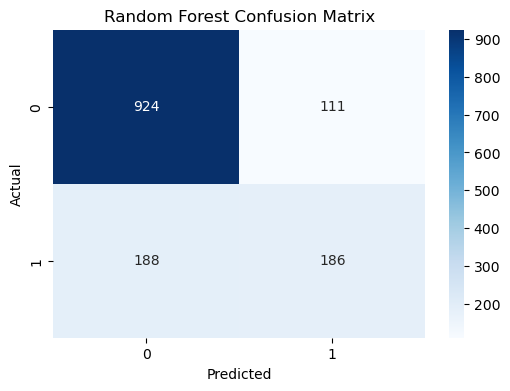

In [45]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix for Random Forest

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [46]:
# Random Forest Feature Importance

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})


feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)


feature_importance.head(10)

,Feature,Importance
18,TotalCharges,0.125830
22,LTV,0.115983
19,Avg_Revenue_Per_Month,0.113424
17,MonthlyCharges,0.113108
4,tenure,0.102304
14,Contract,0.057762
8,OnlineSecurity,0.044126
16,PaymentMethod,0.040316
11,TechSupport,0.036795
9,OnlineBackup,0.025548


In [47]:
import joblib

# Save trained model

joblib.dump(
    rf_model,
    "churn_model.pkl"
)

print("Churn Model Saved Successfully")

Churn Model Saved Successfully


In [48]:
# Save feature names

model_columns = X_train.columns.tolist()

joblib.dump(
    model_columns,
    "model_columns.pkl"
)

print("Model Columns Saved Successfully")

Model Columns Saved Successfully


In [49]:
import os

print(os.listdir())

['.anaconda', '.conda', '.config', '.continuum', '.docker', '.gitconfig', '.ipynb_checkpoints', '.ipython', '.jupyter', '.lesshst', '.matplotlib', '.vscode', '.vscode-shared', '3D Objects', 'anaconda3', 'AppData', 'Application Data', 'churn_columns.pkl', 'churn_model.pkl', 'Cleaned_Telco_Customer_Churn.csv', 'Contacts', 'Cookies', 'customer_churn_ltv_final.csv', 'Data_Cleaning.ipynb', 'Desktop', 'Documents', 'Downloads', 'Erorr.ipynb', 'erreor_2.ipynb', 'Favorites', 'inventory_cleaned.xlsx', 'Inventory_Dataset.xlsx', 'label_encoders.pkl', 'Links', 'Local Settings', 'Microsoft', 'model_columns.pkl', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{53b39e88-18c4-11ea-a811-000d3aa4692b}.TM.blf', 'NTUSER.DAT{53b39e88-18c4-11ea-a811-000d3aa4692b}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{53b39e88-18c4-11ea-a811-000d3aa4692b}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'Pictures', 'PrintHood', 'Rec

In [50]:
# Select features for LTV prediction

ltv_columns = [
    'gender',
    'SeniorCitizen',
    'Partner',
    'Dependents',
    'tenure',
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaperlessBilling',
    'PaymentMethod',
    'MonthlyCharges',
    'TotalCharges',
    'Avg_Revenue_Per_Month',
    'Customer_Age_Group',
    'Customer_Segment'
]

X_ltv = df[ltv_columns]

y_ltv = df["LTV"]


print("Features Shape:", X_ltv.shape)
print("Target Shape:", y_ltv.shape)

Features Shape: (7043, 22)
Target Shape: (7043,)


In [51]:
ltv_categorical_columns = X_ltv.select_dtypes(include="object").columns.tolist()

print(ltv_categorical_columns)

[]


In [52]:
from sklearn.model_selection import train_test_split

X_train_ltv, X_test_ltv, y_train_ltv, y_test_ltv = train_test_split(
    X_ltv,
    y_ltv,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train_ltv.shape)
print("Testing Data:", X_test_ltv.shape)

Training Data: (5634, 22)
Testing Data: (1409, 22)


In [53]:
from sklearn.preprocessing import StandardScaler

ltv_scaler = StandardScaler()

X_train_ltv_scaled = ltv_scaler.fit_transform(X_train_ltv)

X_test_ltv_scaled = ltv_scaler.transform(X_test_ltv)

print("LTV Feature Scaling Completed")

LTV Feature Scaling Completed


In [54]:
from sklearn.linear_model import LinearRegression

lr_ltv_model = LinearRegression()

lr_ltv_model.fit(
    X_train_ltv_scaled,
    y_train_ltv
)

print("Linear Regression LTV Model Trained")

Linear Regression LTV Model Trained


In [55]:
from sklearn.ensemble import RandomForestRegressor

rf_ltv_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_ltv_model.fit(
    X_train_ltv,
    y_train_ltv
)

print("Random Forest LTV Model Trained")

Random Forest LTV Model Trained


In [56]:
# Predictions

lr_ltv_pred = lr_ltv_model.predict(X_test_ltv_scaled)

rf_ltv_pred = rf_ltv_model.predict(X_test_ltv)

print("LTV Predictions Completed")

LTV Predictions Completed


In [57]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Linear Regression Evaluation

lr_mae = mean_absolute_error(y_test_ltv, lr_ltv_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test_ltv, lr_ltv_pred))
lr_r2 = r2_score(y_test_ltv, lr_ltv_pred)


# Random Forest Evaluation

rf_mae = mean_absolute_error(y_test_ltv, rf_ltv_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test_ltv, rf_ltv_pred))
rf_r2 = r2_score(y_test_ltv, rf_ltv_pred)


results_ltv = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest Regressor"
    ],
    "MAE": [
        lr_mae,
        rf_mae
    ],
    "RMSE": [
        lr_rmse,
        rf_rmse
    ],
    "R2 Score": [
        lr_r2,
        rf_r2
    ]
})


results_ltv

,Model,MAE,RMSE,R2 Score
0,Linear Regression,50.421001,78.468243,0.998817
1,Random Forest Regressor,41.611817,64.033473,0.999212


## Evaluate the LTV Prediction Model

The performance of the LTV model is measured using Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score.

In [58]:
ltv_importance = pd.DataFrame({
    "Feature": X_train_ltv.columns,
    "Importance": rf_ltv_model.feature_importances_
})


ltv_importance = ltv_importance.sort_values(
    by="Importance",
    ascending=False
)


ltv_importance.head(10)

,Feature,Importance
18,TotalCharges,0.998928
4,tenure,0.000338
20,Customer_Age_Group,0.000198
19,Avg_Revenue_Per_Month,0.000122
17,MonthlyCharges,0.000122
16,PaymentMethod,0.000041
14,Contract,0.000030
6,MultipleLines,0.000022
9,OnlineBackup,0.000020
0,gender,0.000018


## LTV Feature Importance

Feature importance analysis is performed to identify which variables contribute the most to Customer Lifetime Value prediction.

In [59]:
import joblib

# Save Random Forest LTV model

joblib.dump(
    rf_ltv_model,
    "ltv_model.pkl"
)

print("LTV Model Saved Successfully")

LTV Model Saved Successfully


In [60]:
joblib.dump(
    ltv_scaler,
    "ltv_scaler.pkl"
)

print("LTV Scaler Saved Successfully")

LTV Scaler Saved Successfully


In [61]:
ltv_model_columns = X_ltv.columns.tolist()

joblib.dump(
    ltv_model_columns,
    "ltv_columns.pkl"
)

print("LTV Columns Saved Successfully")

LTV Columns Saved Successfully


In [62]:
import os

files = [
    "ltv_model.pkl",
    "ltv_scaler.pkl",
    "ltv_columns.pkl"
]

for file in files:
    print(file, "→", os.path.exists(file))

ltv_model.pkl → True
ltv_scaler.pkl → True
ltv_columns.pkl → True


In [63]:
# Take one customer sample

sample_customer = X_ltv.iloc[0:1]

prediction = rf_ltv_model.predict(sample_customer)

print("Predicted LTV:", prediction[0])

Predicted LTV: 29.931999999999984


In [64]:
import joblib

# Save final model

joblib.dump(
    rf_ltv_model,
    "ltv_model.pkl"
)

print("Final LTV Model Saved")

Final LTV Model Saved


In [65]:
joblib.dump(
    X_ltv.columns.tolist(),
    "model_columns.pkl"
)

print("LTV Feature Columns Saved")

LTV Feature Columns Saved


## Save the LTV Model

The trained LTV model, scaler, and feature columns are saved using Joblib for future predictions through the API.

In [66]:
import os

for file in [
    "ltv_model.pkl",
    "model_columns.pkl"
]:
    print(file, ":", os.path.getsize(file), "bytes")

ltv_model.pkl : 49765937 bytes
model_columns.pkl : 361 bytes


In [69]:
%%writefile app.py

from fastapi import FastAPI
from pydantic import BaseModel
import pandas as pd
import joblib


app = FastAPI(
    title="Customer LTV Prediction API"
)


model = joblib.load("ltv_model.pkl")

model_columns = joblib.load("model_columns.pkl")


class CustomerData(BaseModel):

    gender: int
    SeniorCitizen: int
    Partner: int
    Dependents: int
    tenure: int
    PhoneService: int
    MultipleLines: int
    InternetService: int
    OnlineSecurity: int
    OnlineBackup: int
    DeviceProtection: int
    TechSupport: int
    StreamingTV: int
    StreamingMovies: int
    Contract: int
    PaperlessBilling: int
    PaymentMethod: int
    MonthlyCharges: float
    TotalCharges: float
    Avg_Revenue_Per_Month: float
    Customer_Age_Group: int
    Customer_Segment: int


@app.get("/")
def home():
    return {
        "message": "LTV Prediction API Running"
    }


@app.post("/predict")
def predict(data: CustomerData):

    input_df = pd.DataFrame([data.dict()])

    prediction = model.predict(input_df)

    return {
        "Predicted_LTV": float(prediction[0])
    }

Writing app.py


## FastAPI Development

A FastAPI application is created to expose the trained LTV prediction model through REST API endpoints. This enables real-time predictions using HTTP requests.

In [72]:
from fastapi import FastAPI
from pydantic import BaseModel
import pandas as pd
import joblib


# Initialize FastAPI app

app = FastAPI(
    title="Customer LTV Prediction API",
    description="API for predicting Customer Lifetime Value",
    version="1.0"
)


# Load trained model and columns

model = joblib.load("ltv_model.pkl")

model_columns = joblib.load("model_columns.pkl")


# Input data format

class CustomerData(BaseModel):

    gender: int
    SeniorCitizen: int
    Partner: int
    Dependents: int
    tenure: int
    PhoneService: int
    MultipleLines: int
    InternetService: int
    OnlineSecurity: int
    OnlineBackup: int
    DeviceProtection: int
    TechSupport: int
    StreamingTV: int
    StreamingMovies: int
    Contract: int
    PaperlessBilling: int
    PaymentMethod: int
    MonthlyCharges: float
    TotalCharges: float
    Avg_Revenue_Per_Month: float
    Customer_Age_Group: int
    Customer_Segment: int


# Home endpoint

@app.get("/")
def home():

    return {
        "message": "Customer LTV Prediction API is Running"
    }


# Prediction endpoint

@app.post("/predict")
def predict(data: CustomerData):

    # Convert input into dataframe

    input_df = pd.DataFrame([data.dict()])


    # Arrange columns in same order as training

    input_df = input_df[model_columns]


    # Predict LTV

    prediction = model.predict(input_df)


    return {
        "Predicted_LTV": round(float(prediction[0]), 2)
    }

## API Testing

The API was tested using FastAPI's interactive Swagger UI. Sample customer data was submitted to the prediction endpoint, and the API successfully returned the predicted Customer Lifetime Value.

### Swagger Documentation

**Local URL:**

https://customer-churn-prediction-ltv-engine.onrender.com/docs



## Conclusion

In Week 3, a Customer Lifetime Value prediction model was successfully developed, evaluated, and deployed using FastAPI. The API enables real-time LTV prediction and forms the deployment component of the Customer Churn Prediction and LTV Engine project.